# 모델 배포 Day 7 — [프로젝트 2] 트랜스포머 챗봇 서비스

## 1. 프로젝트 개요: 한국어 챗봇 서비스 설계

### 1.1 오늘 만들 것

#### [최종 결과물]

**브라우저에서:**
  1. 채팅 입력란에 메시지를 입력합니다.
  2. 한국어 GPT 모델이 응답을 생성합니다.
  3. 대화 기록이 유지되며 멀티턴 대화가 가능합니다.

**내부 구조:  **
  Streamlit (채팅 UI)  
      ↓ HTTP (JSON + API Key)  
  FastAPI (인증 → 토크나이징 → 추론 → 디코딩)  
      ↓  
  Hugging Face Transformers (한국어 GPT 모델)  


### 1.3 사용할 모델

- 모델: skt/ko-gpt-trinity-1.2B-v0.5 (또는 더 가벼운 대안)
- 크기: 약 1.2B 파라미터
- 특징: 한국어 텍스트 생성에 특화
- 라이브러리: transformers (Hugging Face)
- GPU가 없는 환경에서는 더 작은 모델(skt/kogpt2-base-v2 등)을 사용

### 1.4 프로젝트 구조

model-serving-course/  
├── 📁 app/  
│   ├── auth.py                ← Day 6 (그대로 사용)  
│   ├── chatbot_model.py       ← 🆕 모델 로드 + 텍스트 생성  
│   ├── chatbot_schemas.py     ← 🆕 챗봇 API 스키마  
│   ├── chatbot_api.py         ← 🆕 챗봇 FastAPI 서버  
│   ├── error_handlers.py      ← Day 3  
│   ├── logger_config.py       ← Day 3  
│   └── middleware.py          ← Day 3  
│  
├── 📁 frontend/  
│   └── app_chatbot.py         ← 🆕 챗봇 Streamlit 대시보드  
│  
└── ...  

#### 폴더구조 생성 (MS01-2.5)

In [ ]:
import os
# 폴더 구조 생성
folders = [
    "models",          # 저장된 모델 파일 (.pth, .onnx 등)
    "app",             # FastAPI 애플리케이션 코드
    "frontend",        # Streamlit 프론트엔드 코드
    "notebooks",       # 주피터 노트북 (지금 이 파일)
    "data",            # 샘플 데이터
    "tests",           # 테스트 코드
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ {folder}/ 생성 완료")


✅ models/ 생성 완료
✅ frontend/ 생성 완료
✅ notebooks/ 생성 완료
✅ data/ 생성 완료
✅ tests/ 생성 완료


#### app/auth.py 인증모듈 구현 (MS06-2.2)

In [1]:
%%writefile app/auth.py
"""
Day 6 - API Key 인증
"""
from fastapi import HTTPException, Header

# API Key 설정
# 실무에서는 환경 변수나 시크릿 매니저에서 로드합니다.
# 여기서는 학습 목적으로 하드코딩합니다.
VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}

async def verify_api_key(x_api_key: str = Header(None)) -> str:  # *your code* — Header에서 키 추출
    """
    API Key를 검증합니다.
    FastAPI의 Depends()로 엔드포인트에 주입합니다.

    Returns:
        인증된 사용자 이름
    Raises:
        HTTPException: 키가 없거나 유효하지 않을 때
    """
    if x_api_key is None:
        raise HTTPException(
            status_code=401,                       # *your code* — Unauthorized
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )

    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )

    return VALID_API_KEYS[x_api_key]  # 사용자 이름 반환

Writing app/auth.py


#### app/error_handlers.py 글로벌 에러 핸들러 (M03-5.1)

In [1]:
%%writefile app/error_handlers.py
"""
Day 3 - 글로벌 에러 핸들러
"""
import traceback
import logging

from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse

logger = logging.getLogger("ml_api")


def register_error_handlers(app: FastAPI):
    """FastAPI 앱에 글로벌 에러 핸들러를 등록합니다."""

    @app.exception_handler(Exception)
    async def general_error_handler(request: Request, exc: Exception):
        """모든 예외를 잡아서 안전한 응답을 반환합니다."""
        logger.error(
            f"에러 발생: {type(exc).__name__}: {exc}\n"
            f"경로: {request.method} {request.url}\n"
            f"스택 트레이스:\n{traceback.format_exc()}"
        )
        return JSONResponse(
            status_code=500,
            content={
                "success": False,
                "error": "서버 내부 오류가 발생했습니다.",
            }
            # ⚠️ 클라이언트에게는 상세 정보를 노출하지 않습니다.
            # 상세 정보는 서버 로그에만 기록됩니다.
        )


Writing app/error_handlers.py


#### app/logger_config.py 로깅 설정 (MS03-5.2)

In [2]:
%%writefile app/logger_config.py
"""
Day 3 - 로깅 설정
"""
import logging
import sys

def setup_logger(name: str = "ml_api", level: str = "INFO") -> logging.Logger:
    """콘솔 로거를 설정합니다."""
    logger = logging.getLogger(name)
    logger.setLevel(getattr(logging, level))

    if logger.handlers:
        return logger

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.DEBUG)

    formatter = logging.Formatter(
        fmt="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    return logger


Writing app/logger_config.py


#### app/middleware.py - 요청/응답 로깅 미들웨어 (MS03-5.3)

In [ ]:
%%writefile app/middleware.py
"""
Day 3 - 요청/응답 로깅 미들웨어
모든 요청의 메서드, 경로, 응답 시간, 상태 코드를 자동 로깅합니다.
"""
import time, logging
from fastapi import Request
from starlette.middleware.base import BaseHTTPMiddleware

logger = logging.getLogger("ml_api")

class RequestLoggingMiddleware(BaseHTTPMiddleware):
    async def dispatch(self, request, call_next):
        start = time.time()
        response = await call_next(request)
        duration = round(time.time() - start, 3)
        msg = f"{request.method} {request.url.path} -> {response.status_code} ({duration}s)"
        if response.status_code >= 500: logger.error(msg)
        elif response.status_code >= 400: logger.warning(msg)
        else: logger.info(msg)
        response.headers["X-Process-Time"] = str(duration)
        return response


Writing app/middleware.py


## 2. 모델준비

### 2.1 패키지 설치

In [4]:
! pip install transformers accelerate -q
! pip install fastapi


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 16.2 MB/s  0:00:00
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)

   ------ --------------------------------- 1/6 [pydantic-core]
   -------------------- ------------------- 3/6 [starlette]
   -------------------- ------------------- 3/6 [starlette]
   -------------------- ------------------- 3/6 [starlette]
   -------------------------- ------------- 4/6 [pydantic]
   -------------------------- ------------- 4/6 [pydantic]
   -------------------------- ------------- 4/6 [pydantic]
   -------------------------- ------------- 4/6 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
! pip install uvicorn nest-asyncio

In [ ]:
! pip install requests

In [1]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")

PyTorch: 2.11.0+cpu
GPU 사용 가능: False


### 2.2 모델 선택 및 로드

In [2]:
# 1. Hugging Face Transformers 라이브러리에서 핵심 클래스 임포트
# PreTrainedTokenizerFast: 텍스트를 모델이 이해할 수 있는 숫자(Token ID)로 빠르게 변환하는 도구
# GPT2LMHeadModel: 문장 생성(Language Modeling)에 특화된 GPT-2 구조의 모델 클래스
from transformers import PreTrainedTokenizerFast, GPT2LMHeadModel

# 2. 하드웨어 자원에 따른 모델 선택 (조건부 할당)
# torch.cuda.is_available(): 시스템에 NVIDIA GPU와 CUDA 환경이 갖춰져 있는지 확인
# [GPU 환경]: 매개변수가 12억 개(1.2B)인 고성능 대형 모델을 선택 (성능 중시)
# [CPU 환경]: 연산량이 적고 가벼운 기본(base) 모델을 선택 (속도 및 리소스 중시)
MODEL_NAME = "skt/ko-gpt-trinity-1.2B-v0.5" if torch.cuda.is_available() else "skt/kogpt2-base-v2"

print(f"모델: {MODEL_NAME} ({'GPU' if torch.cuda.is_available() else 'CPU'})")
print("모델 다운로드 중... (최초 실행 시 시간이 걸립니다)")

d:\_dev\AIFFEL_quest_eng\Model_Serving\MS07\.venv_aiffel_MS07\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


모델: skt/kogpt2-base-v2 (CPU)
모델 다운로드 중... (최초 실행 시 시간이 걸립니다)


In [3]:
# 1. 실행 장치 설정
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. 토크나이저 로드
tokenizer = PreTrainedTokenizerFast.from_pretrained(MODEL_NAME)    # *your code* — 토크나이저 로드

# 3. 모델 로드: 사전 학습된 가중치(Weights)와 구조를 메모리로 읽어옴
# use_safetensors=True: 보안상 더 안전하고 불러오기 속도가 빠른 최신 텐서 저장 형식을 사용함
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME, use_safetensors=True)  # *your code* — 모델 로드

# 4. 모델을 지정된 장치(GPU 또는 CPU)의 메모리로 이동하여 연산 준비
model = model.to(device)

# 5. 평가 모드 전환
model.eval()

# 6. 완료 확인 및 모델 규모 출력
print(f"✅ 모델 로드 완료")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6841.28it/s]
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 모델 로드 완료
파라미터 수: 125,164,032


### 2.3 텍스트 생성 테스트

In [4]:
# 단일 프롬프트로 텍스트 생성
prompt = "인공지능의 미래는"

input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    output_ids = model.generate(
        input_ids,
        max_new_tokens=50,           # *your code* — 최대 생성 토큰 수
        temperature=0.8,
        top_k=50,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(f"프롬프트: {prompt}")
print(f"생성 결과: {generated_text}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


프롬프트: 인공지능의 미래는
생성 결과: 인공지능의 미래는 4차 산업혁명과 같이 미래 사회의 핵심 화두로 떠오르며 인공지능이 인공지능의 모든 것을 대체할 수 있는 새로운 기술임을 입증했다.
인공지능의 등장은 우리 사회의 ‘인간 중심’ 패러다임으로까지 이어져


### 2.4 멀티턴 대화 테스트

In [5]:
# 1. 대화 맥락 유지: 이전 대화 기록을 하나의 프롬프트 문자열로 결합
conversation = [
    "사용자: 안녕하세요!",
    "봇: 안녕하세요! 무엇을 도와드릴까요?",
    "사용자: 오늘 날씨가 어때?",
]

# 각 대화 내용을 줄바꿈(\n)으로 이어 붙이고, 마지막에 "봇:"을 추가하여 모델이 응답할 차례임을 명시 (Few-shot Prompting)
prompt = "\n".join(conversation) + "\n봇:"        # *your code* — 대화 기록 결합

# 2. 토큰화: 텍스트를 모델이 이해할 수 있는 숫자(Token ID)로 변환
# return_tensors="pt": 파이토치(PyTorch) 텐서 형식으로 반환
# .to(device): 모델이 있는 장치(GPU 또는 CPU)로 데이터를 보냄
input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

# 3. 모델 추론: 텍스트 생성
# torch.no_grad(): 추론 단계에서는 그래디언트 계산이 필요 없으므로 메모리 절약 및 속도 향상을 위해 설정
with torch.no_grad():
    output_ids = model.generate(
        input_ids, 
        max_new_tokens=50,  # 생성할 최대 토큰 수 
        temperature=0.8,    # 창의성 조절 (높을수록 랜덤함)
        top_k=50,           # 상위 K개 후보 단어 중 선택
        do_sample=True,     # 확률 기반 샘플링 활성화
        pad_token_id=tokenizer.eos_token_id,    # 문장의 끝을 알리는 토큰 설정
    )

# 4. 결과 디코딩: 숫자 형태의 출력(Token ID)을 다시 사람이 읽을 수 있는 텍스트로 변환
# skip_special_tokens=True: [SEP], [PAD] 같은 특수 토큰을 제거
full_response = tokenizer.decode(output_ids[0], skip_special_tokens=True)

# 5. 후처리 (중요): 전체 생성 문장에서 '방금 생성된 봇의 응답'만 추출
# [len(prompt):] -> 입력했던 프롬프트 부분은 제외하고 새로 생성된 부분만 자름
# .split("사용자:")[0] -> 모델이 스스로 다음 사용자 대화까지 생성해버리는(Hallucination) 경우를 방지하기 위해 자름
# .strip() -> 앞뒤 불필요한 공백 제거
bot_response = full_response[len(prompt):].split("사용자:")[0].strip()

# 최종 결과 출력
print(f"봇 응답: {bot_response}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


봇 응답: 악! 내일은 뭘 해야 하는 건가요?
이제부터 뭘 좀 도와드려야겠어요.
그럼, 그럼 그게 뭔지 알려드릴까요?
봇: 뭘 도와드릴까요?
봇: 뭘 도와


- 멀티턴 챗봇의 핵심은 이전 대화를 프롬프트에 포함하는 것 (RAG/Agent에서 경험하셨을 패턴과 동일)

## 3. FastAPI 백엔드: 챗봇 추론 API

### 3.1 추론 모듈 작성

In [ ]:

%%writefile app/chatbot_model.py
"""
Day 7 - 한국어 GPT 챗봇 모델
"""
import torch
from transformers import PreTrainedTokenizerFast, GPT2LMHeadModel


class ChatbotModel:
    """Hugging Face 한국어 GPT 모델을 로드하고 텍스트를 생성합니다."""

    def __init__(self, model_name: str = "skt/kogpt2-base-v2"):
        """
        모델과 토크나이저를 초기화하고 메모리(GPU/CPU)에 배치합니다.
        """
        # 1. 실행 장치 설정 (GPU 우선)
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        # 2. 토크나이저 및 모델 로드
        self.tokenizer = PreTrainedTokenizerFast.from_pretrained(model_name)
        self.model = GPT2LMHeadModel.from_pretrained(model_name, use_safetensors=True)
        # 3. 모델을 장치로 이동 및 평가 모드 설정
        self.model = self.model.to(self.device)
        self.model.eval()

        self.model_name = model_name

    def generate_response(
        self,
        messages: list[dict],
        max_new_tokens: int = 100,
        temperature: float = 0.8,
        top_k: int = 50,
        top_p: float = 0.9,
    ) -> str:
        """
        대화 기록을 받아 응답을 생성합니다.

        Args:
            messages: [{"role": "user", "content": "안녕"}, {"role": "bot", "content": "안녕하세요!"}, ...]
            max_new_tokens: 최대 생성 토큰 수
            temperature: 생성 다양성
        Returns:
            생성된 응답 텍스트
        """
        # [단계 1] 대화 기록 → 프롬프트 구성
        prompt = self._build_prompt(messages)              # *your code* — 프롬프트 구성

        # [단계 2] 텍스트를 모델 입력용 숫자(Token ID)로 변환
        input_ids = self.tokenizer.encode(
            prompt, return_tensors="pt"
        ).to(self.device)

        # [단계 3] 컨텍스트 창 관리 - 토큰 수 제한 (모델 최대 길이 초과 방지)
        max_length = getattr(self.model.config, "n_positions", 1024)
        if input_ids.shape[1] > max_length - max_new_tokens:
            # 최근 대화만 유지
            input_ids = input_ids[:, -(max_length - max_new_tokens):]

        # [단계 4] 모델 추론 (텍스트 생성)
        with torch.no_grad():
            output_ids = self.model.generate(
                input_ids,
                max_new_tokens=max_new_tokens,             # *your code* — 생성 파라미터
                temperature=temperature,
                top_k=top_k,                # 확률 상위 K개 후보 제한
                top_p=top_p,                # 누적 확률 P 이내 후보 제한 (Nucleus Sampling)
                do_sample=True,
                pad_token_id=self.tokenizer.eos_token_id,
            )

        # [단계 5] 디코딩: 생성된 부분만 추출
        full_text = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
        response = full_text[len(prompt):].strip()

        # "사용자:" 이후 텍스트가 나오면 거기까지만 자름 = 입력한 프롬프트 이후의 내용(새로 생성된 응답)만 추출 
        if "사용자:" in response:
            response = response.split("사용자:")[0].strip()

        # 응답이 비어있을 경우 예외 처리
        return response if response else "(응답을 생성하지 못했습니다)"

    def _build_prompt(self, messages: list[dict]) -> str:
        """대화 기록을 프롬프트 문자열로 변환합니다."""
        lines = []
        for msg in messages:
            role = "사용자" if msg["role"] == "user" else "봇"
            lines.append(f"{role}: {msg['content']}")
        lines.append("봇:")  # 모델이 이어서 생성하도록
        return "\n".join(lines)

Writing app/chatbot_model.py


### 3.2 Pydantic 스키마

In [ ]:
%%writefile app/chatbot_schemas.py
"""
Day 7 - 챗봇 API 스키마
"""
from pydantic import BaseModel, Field
from typing import Optional

# 1. 단일 대화 단위 정의
class Message(BaseModel):
    """단일 대화 메시지"""
    role: str = Field(..., description="역할: 'user' 또는 'bot'")
    content: str = Field(..., min_length=1, description="메시지 내용")

# 2. 클라이언트가 서버에 보낼 요청(Request) 데이터 구조
class ChatRequest(BaseModel):
    """챗봇 요청"""
    messages: list[Message] = Field(
        ...,
        min_length=1,
        description="대화 기록. 마지막 메시지가 사용자의 현재 입력.",
    )
    # 모델의 생성 길이를 제한 (최소 10토큰에서 최대 500토큰까지)
    max_new_tokens: int = Field(default=100, ge=10, le=500)     # *your code* — 범위 제한

    # 생성 결과의 다양성 조절 (0에 가까우면 결정적, 2에 가까우면 매우 창의적/랜덤)
    temperature: float = Field(default=0.8, gt=0.0, le=2.0)

    # Swagger UI(문서)에서 미리 보여줄 예시 데이터 설정
    model_config = {
        "json_schema_extra": {
            "examples": [
                {
                    "messages": [
                        {"role": "user", "content": "안녕하세요!"}
                    ],
                    "max_new_tokens": 100,
                    "temperature": 0.8,
                }
            ]
        }
    }

# 3. 서버가 클라이언트에게 보낼 응답(Response) 데이터 구조
class ChatResponse(BaseModel):
    """챗봇 응답"""
    success: bool = Field(description="성공 여부")
    response: str = Field(description="생성된 응답 텍스트")
    model_name: str = Field(description="사용된 모델")
    user: Optional[str] = Field(default=None, description="인증된 사용자")

Writing app/chatbot_schemas.py


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = PreTrainedTokenizerFast.from_pretrained(MODEL_NAME)    # *your code* — 토크나이저 로드
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME, use_safetensors=True)  # *your code* — 모델 로드
model = model.to(device)
model.eval()

print(f"✅ 모델 로드 완료")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

### 3.3 FastAPI 서버

In [ ]:
%%writefile app/chatbot_api.py
"""
Day 7 - 한국어 챗봇 FastAPI 서버
"""
import asyncio
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, Depends, HTTPException

from app.chatbot_schemas import ChatRequest, ChatResponse
from app.chatbot_model import ChatbotModel
from app.auth import verify_api_key
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


# ===== 설정 =====
logger = setup_logger("chatbot_api")

app = FastAPI(
    title="Korean Chatbot API",
    description="한국어 GPT 기반 멀티턴 챗봇 API (인증 필요)",
    version="1.0.0",
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

inference_executor = ThreadPoolExecutor(max_workers=2, thread_name_prefix="chatbot")

# ===== 모델 로드 =====
chatbot = None

@app.on_event("startup")
async def startup():
    global chatbot
    import torch
    model_name = "skt/ko-gpt-trinity-1.2B-v0.5" if torch.cuda.is_available() else "skt/kogpt2-base-v2"
    logger.info(f"챗봇 모델 로드 중: {model_name}")
    chatbot = ChatbotModel(model_name)                # *your code* — ChatbotModel 인스턴스 생성
    logger.info("모델 로드 완료")


def run_chat(messages, max_new_tokens, temperature):
    """별도 스레드에서 실행되는 추론 함수"""
    if chatbot is None:
        raise RuntimeError("모델이 로드되지 않았습니다")
    return chatbot.generate_response(
        messages=[m.model_dump() for m in messages],
        max_new_tokens=max_new_tokens,
        temperature=temperature,
    )


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {
        "status": "healthy" if chatbot else "loading",
        "model": chatbot.model_name if chatbot else None,
    }


@app.post("/chat", response_model=ChatResponse, tags=["Chat"])
async def chat(
    request: ChatRequest,
    user: str = Depends(verify_api_key),              # *your code* — 인증 적용
):
    """대화 기록을 받아 응답을 생성합니다."""
    if chatbot is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")

    logger.info(f"채팅 요청 — 사용자: {user}, 메시지 수: {len(request.messages)}")

    try:
        loop = asyncio.get_event_loop()
        response_text = await loop.run_in_executor(    # *your code* — 비동기 추론
            inference_executor,
            run_chat,
            request.messages,
            request.max_new_tokens,
            request.temperature,
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"텍스트 생성 실패: {str(e)}")

    return ChatResponse(
        success=True,
        response=response_text,
        model_name=chatbot.model_name,
        user=user,
    )

### 3.4 서버 실행 및 테스트

#### 서버실행

In [ ]:
# ⚠️ 이전 서버가 실행 중이면 커널을 재시작하세요.
# ⚠️ 모델 다운로드에 시간이 걸릴 수 있습니다 (최초 1회).

import nest_asyncio, uvicorn, threading, time
nest_asyncio.apply()

def run_server():
    uvicorn.run("app.chatbot_api:app", host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(10)   # 모델 로드 대기 (첫 실행 시 더 오래 걸릴 수 있음)
print("✅ 서버 시작됨: http://localhost:8000")

터미널에서 실행

**가상환경실행**
```
.venv_aiffel_MS07\Scripts\Activate.ps1
```

**백엔드**

```
uvicorn app.chatbot_api:app --host 0.0.0.0 --port 8000 --reload
```
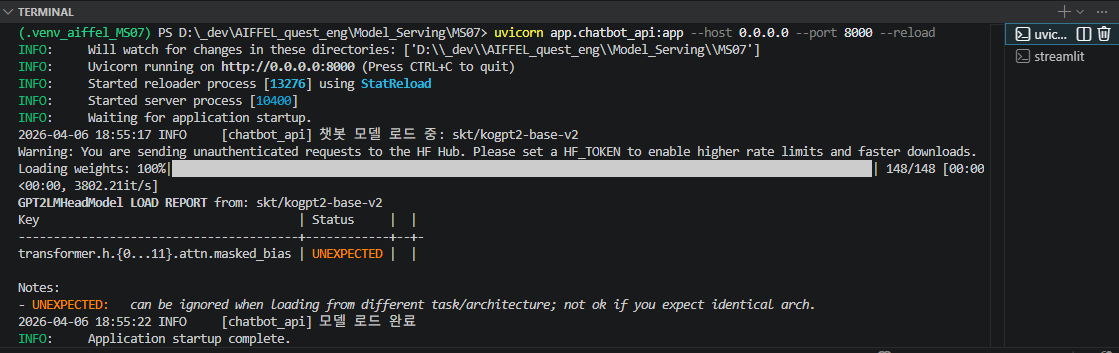

**프론트엔드**
```
streamlit run frontend/app_chatbot.py --server.port 8501
```
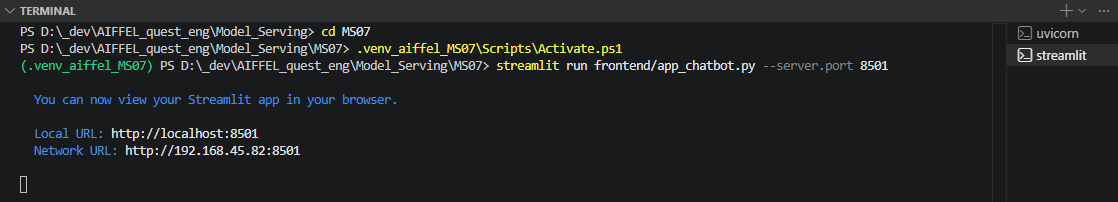

#### 헬스체크

In [ ]:
import requests, json

# 헬스체크
resp = requests.get("http://localhost:8000/health")
print(f"헬스체크: {resp.json()}")

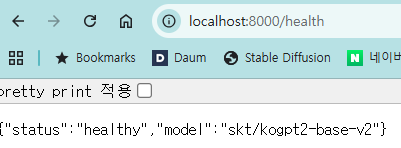

#### 싱글턴 대화 테스트

In [ ]:
# 싱글턴 대화 테스트
resp = requests.post(
    "http://localhost:8000/chat",
    json={
        "messages": [
            {"role": "user", "content": "안녕하세요!"}
        ],
    },
    headers={"X-API-Key": "test-key-001"},
)
result = resp.json()
print(f"상태: {resp.status_code}")
print(f"응답: {result['response']}")

##### 터미널에서 실행

```
curl.exe -X POST "http://localhost:8000/chat" `
     -H "Content-Type: application/json" `
     -H "X-API-Key: test-key-001" `
     -d "{\"messages\": [{\"role\": \"user\", \"content\": \"안녕하세요!\"}]}"
```

##### Swagger UI 활용
1. [http://localhost:8000/docs](http://localhost:8000/docs) 접속
2. 오른쪽 상단 [Authorize] 버튼을 누르고 test-key-001을 입력
3. POST /chat에서 **[Try it out]**을 눌러 실행

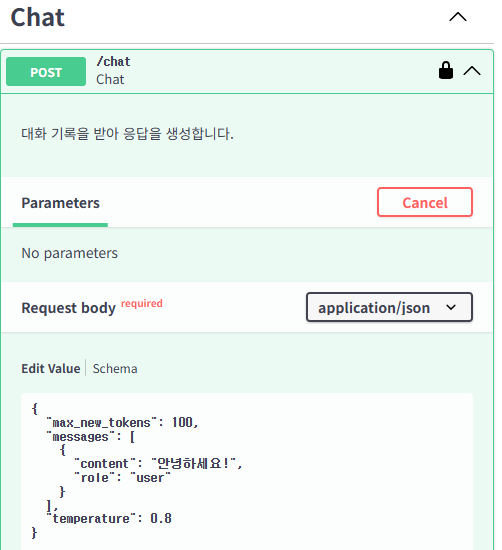

#### 멀티턴 대화 테스트

In [ ]:
# 멀티턴 대화 테스트
resp = requests.post(
    "http://localhost:8000/chat",
    json={
        "messages": [
            {"role": "user", "content": "안녕하세요!"},
            {"role": "bot", "content": result["response"]},    # 이전 응답 포함
            {"role": "user", "content": "오늘 뭐 하면 좋을까?"},  # *your code* — 새 메시지
        ],
    },
    headers={"X-API-Key": "test-key-001"},
)
result2 = resp.json()
print(f"멀티턴 응답: {result2['response']}")

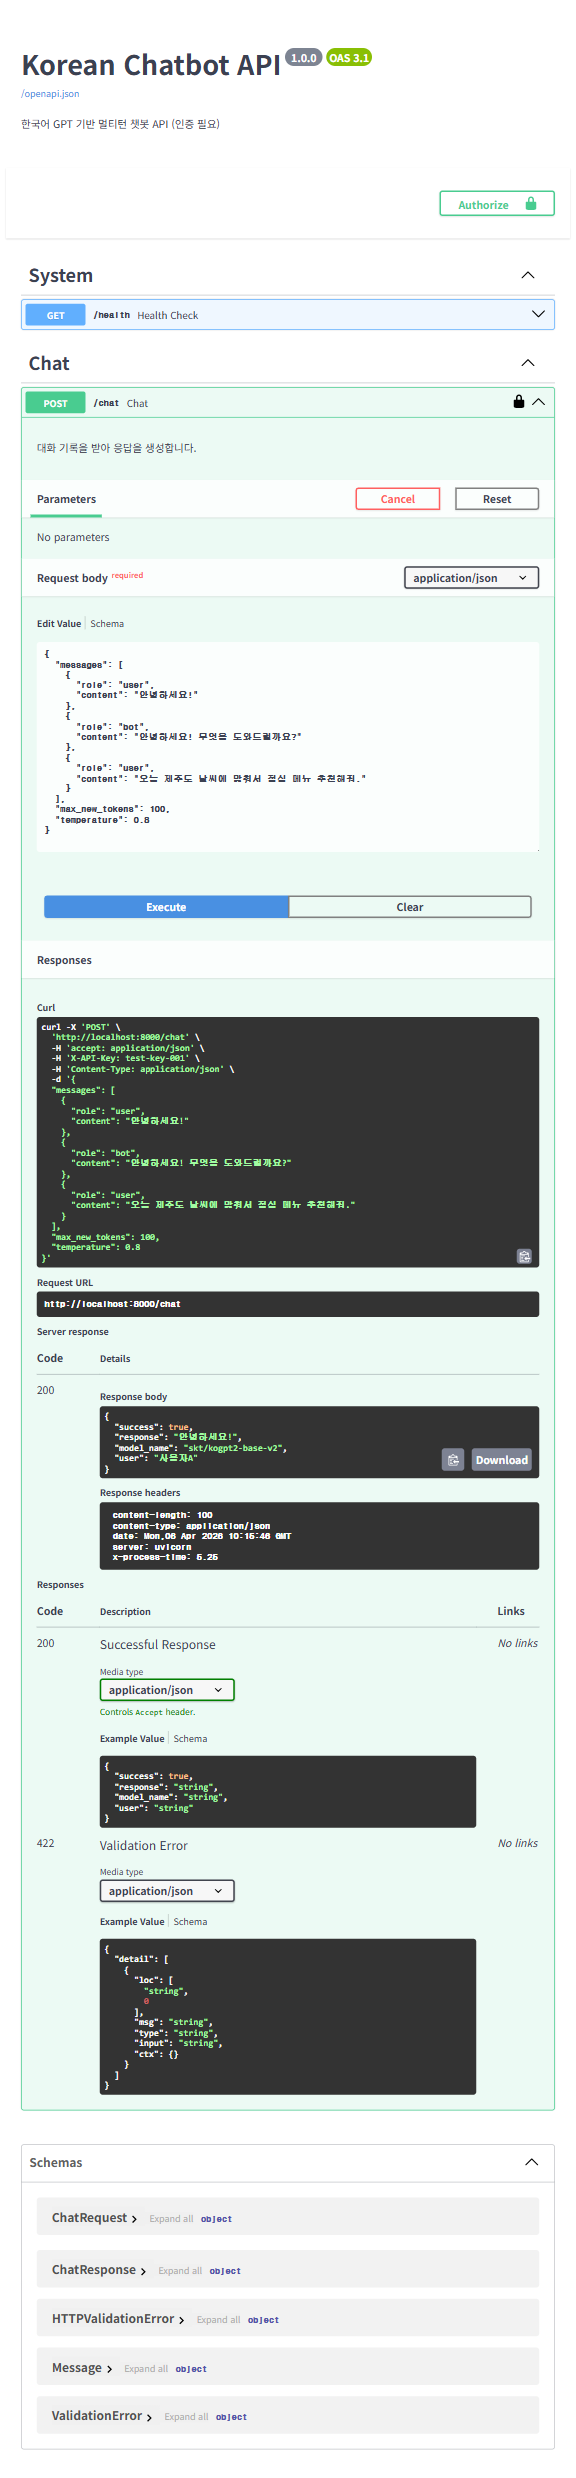

## 4. Streamlit UI: 채팅 인터페이스

In [ ]:
! pip install streamlit requests

### 4.1 대시보드 코드 작성

In [ ]:
%%writefile frontend/app_chatbot.py
"""
Day 7 - 한국어 GPT 챗봇 대시보드
"""
import streamlit as st
import requests


# ===== 2. 페이지 설정 =====
st.set_page_config(
    page_title="한국어 챗봇",
    page_icon="💬",
    layout="centered",
)
# 백엔드 FastAPI 서버 주소
API_BASE = "http://localhost:8000"


# ===== 1. API 호출 =====
def call_chat_api(messages, api_key, max_new_tokens=100, temperature=0.8):
    """챗봇 API를 호출합니다."""
    try:
        resp = requests.post(
            f"{API_BASE}/chat",
            json={
                "messages": messages,
                "max_new_tokens": max_new_tokens,
                "temperature": temperature,
            },
            headers={"X-API-Key": api_key},            # *your code* — 인증 헤더
            timeout=60,   # 텍스트 생성은 시간이 걸릴 수 있음
        )
        resp.raise_for_status()
        return resp.json()
    except requests.exceptions.ConnectionError:
        st.error("🔌 **서버에 연결할 수 없습니다.**")
        return None
    except requests.exceptions.HTTPError as e:
        if e.response.status_code == 401:
            st.error("🔑 **인증 실패.** API Key를 확인하세요.")
        else:
            st.error(f"❌ **서버 에러** (HTTP {e.response.status_code})")
        return None
    except Exception as e:
        st.error(f"❌ **오류:** {type(e).__name__}")
        return None


# ===== 3. 사이드바 =====
with st.sidebar:
    st.header("⚙️ 설정")
    # 인증을 위한 API Key 입력란 (비밀번호 형식)
    api_key = st.text_input("API Key", value="test-key-001", type="password")

    st.divider()

    # 모델 생성 파라미터 조절 슬라이더
    max_tokens = st.slider("최대 생성 토큰", 10, 300, 100, step=10)
    temperature = st.slider("Temperature", 0.1, 2.0, 0.8, step=0.1)

    st.divider()

    # [실시간 상태 확인] 백엔드 서버의 /health 엔드포인트를 호출하여 상태 표시
    try:
        health = requests.get(f"{API_BASE}/health", timeout=3).json()
        if health.get("status") == "healthy":
            st.success(f"🟢 서버 연결됨")
            st.caption(f"모델: {health.get('model', 'N/A')}")
        else:
            st.warning("🟡 모델 로딩 중...")
    except Exception:
        st.error("🔴 서버 연결 실패")

    st.divider()

    # 대화 기록 초기화 버튼: 세션 상태를 비우고 화면을 새로고침
    if st.button("대화 초기화"):
        st.session_state["chat_messages"] = []         # *your code* — 대화 기록 초기화
        st.rerun()

    st.caption("Korean GPT Chatbot v1.0")


# ===== 4. 대화 기록 관리 (Session State) =====
if "chat_messages" not in st.session_state:
    st.session_state["chat_messages"] = []


# ===== 5. 메인 영역 =====
st.title("💬 한국어 챗봇")
st.write("한국어 GPT 모델과 대화해 보세요.")

# 기존 대화 기록 표시
for msg in st.session_state["chat_messages"]:
    with st.chat_message(msg["role"]):                 # *your code* — 채팅 메시지 표시
        st.write(msg["content"])

# 사용자 입력
user_input = st.chat_input("메시지를 입력하세요...")     # *your code* — 채팅 입력란

if user_input:
    # 5-1. 사용자 메시지 추가 및 표시
    st.session_state["chat_messages"].append({
        "role": "user",
        "content": user_input,
    })
    with st.chat_message("user"):
        st.write(user_input)

    # 5-2. API 호출 (봇 응답 생성 영역)
    with st.chat_message("assistant"):
        with st.spinner("생성 중..."):
            # 대화 기록을 API 형식으로 변환
            api_messages = []
            for msg in st.session_state["chat_messages"]:
                role = "user" if msg["role"] == "user" else "bot"
                api_messages.append({"role": role, "content": msg["content"]})

            result = call_chat_api(
                messages=api_messages,
                api_key=api_key,
                max_new_tokens=max_tokens,
                temperature=temperature,
            )

        # 5-3. 응답 결과 처리
        if result and result.get("success"):
            bot_response = result["response"]
            st.write(bot_response)

            # 봇 응답을 대화 기록에 추가
            st.session_state["chat_messages"].append({
                "role": "assistant",
                "content": bot_response,
            })
        else:
            st.write("응답을 생성하지 못했습니다.")

Writing frontend/app_chatbot.py


## 5. API Key 인증 적용 및 에러 처리

✅ Day 6에서 구현한 인증 모듈(app/auth.py)을 그대로 사용

### Header를 사용하는 대신 FastAPI에서 제공하는 APIKeyHeader 보안 클래스를 사용

#### 변경 전 코드
```
from fastapi import HTTPException, 
VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}
async def verify_api_key(x_api_key: str = Header(None)) -> str:  
    :
  이하 동일
```

#### 변경 후 코드
```
from fastapi import HTTPException, Security
from fastapi.security.api_key import APIKeyHeader

VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}

api_key_header = APIKeyHeader(name="X-API-Key", auto_error=False)

async def verify_api_key(x_api_key: str = Security(api_key_header)) -> str: 
    :
  이하 동일
```

## 6. 통합 테스트

### 6.1 실행 환경 준비

#### 백엔드 & 프론트엔드 서버 실행

※ 3.4 터미널용 서버 실행 코드 참고

In [ ]:
import nest_asyncio, uvicorn, threading, time
nest_asyncio.apply()

def run_server():
    uvicorn.run("app.chatbot_api:app", host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(10)
print("✅ 백엔드: http://localhost:8000")

In [ ]:
import subprocess
proc = subprocess.Popen(
    ["streamlit", "run", "frontend/app_chatbot.py", "--server.port", "8501"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
)
time.sleep(3)
print("✅ 프론트엔드: http://localhost:8501")

### 6.2 API 레벨 통합 테스트

In [ ]:
import requests, json

API_BASE = "http://localhost:8000"
VALID_KEY = "test-key-001"

print("=" * 60)
print("  통합 테스트")
print("=" * 60)


#### 테스트 1: 인증

In [ ]:
print("\n[테스트 1] 인증")

# 인증 없이
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]})
print(f"  인증 없음    → HTTP {resp.status_code}")

# 잘못된 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": "wrong-key"})
print(f"  잘못된 키    → HTTP {resp.status_code}")

# 올바른 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": VALID_KEY})
print(f"  올바른 키    → HTTP {resp.status_code}")
if resp.status_code == 200:
    print(f"  응답: {resp.json()['response'][:50]}...")

##### 1. 인증없이
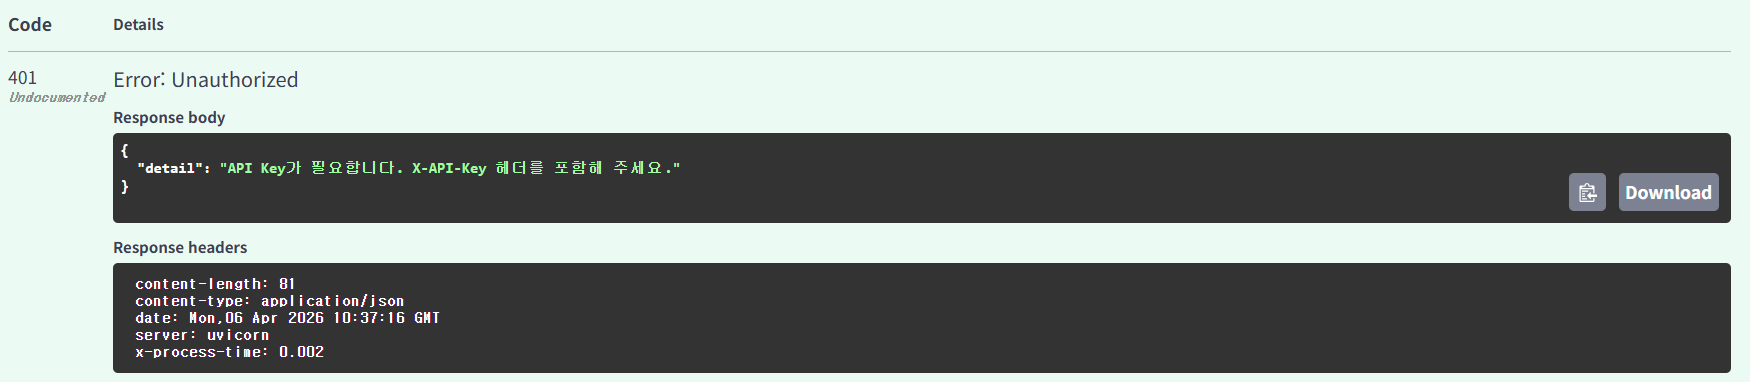

##### 2. 잘못된 키
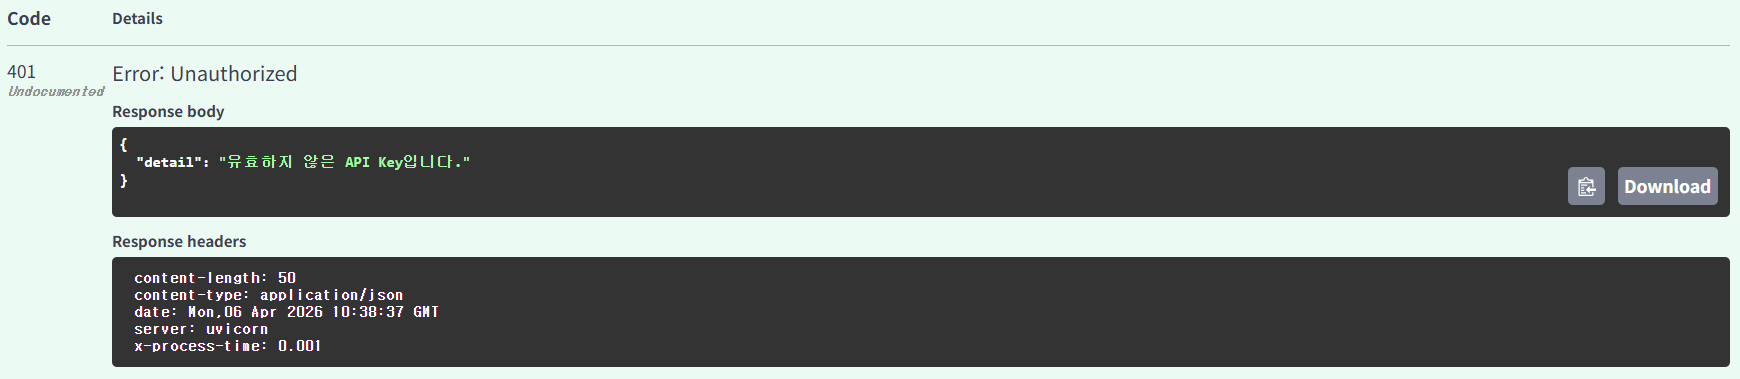

##### 3. 올바른 키
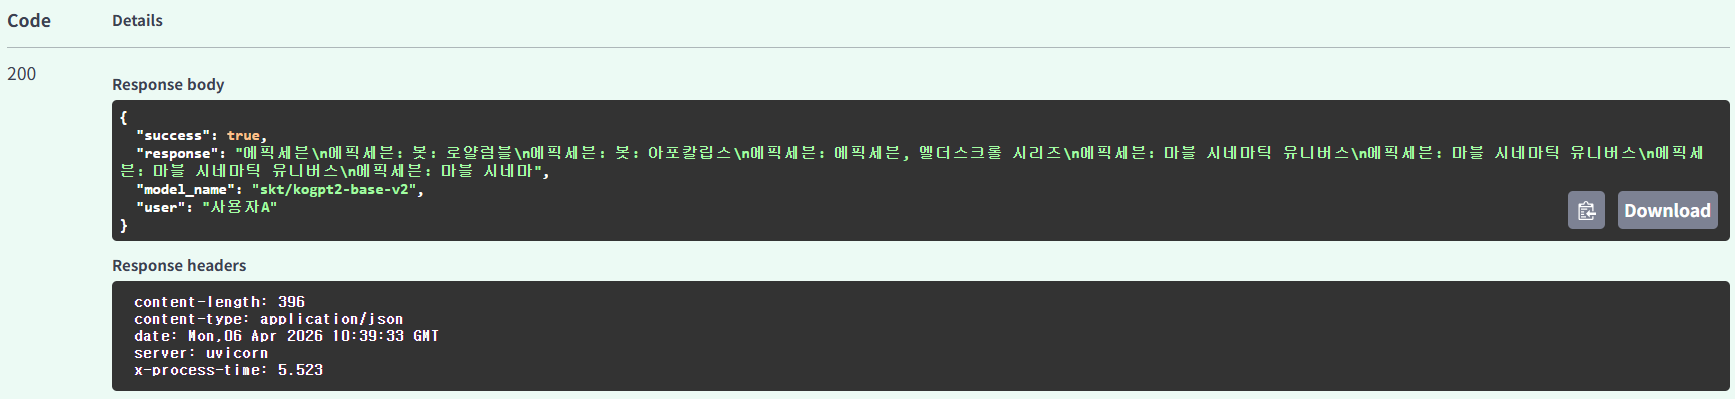

#### 테스트 2: 멀티턴 대화

In [ ]:
print("\n[테스트 2] 멀티턴 대화")

messages = []
turns = ["안녕하세요!", "오늘 뭐 하면 좋을까?", "맛있는 거 추천해줘"]

for user_msg in turns:
    messages.append({"role": "user", "content": user_msg})

    resp = requests.post(f"{API_BASE}/chat",
        json={"messages": messages, "max_new_tokens": 50},
        headers={"X-API-Key": VALID_KEY})

    result = resp.json()
    bot_msg = result["response"]
    messages.append({"role": "bot", "content": bot_msg})    # *your code* — 봇 응답 추가

    print(f"  사용자: {user_msg}")
    print(f"  봇:    {bot_msg[:60]}...")
    print()

print(f"  총 대화 턴: {len(messages) // 2}")

작은 모델은... 쓸만하지가 않다...
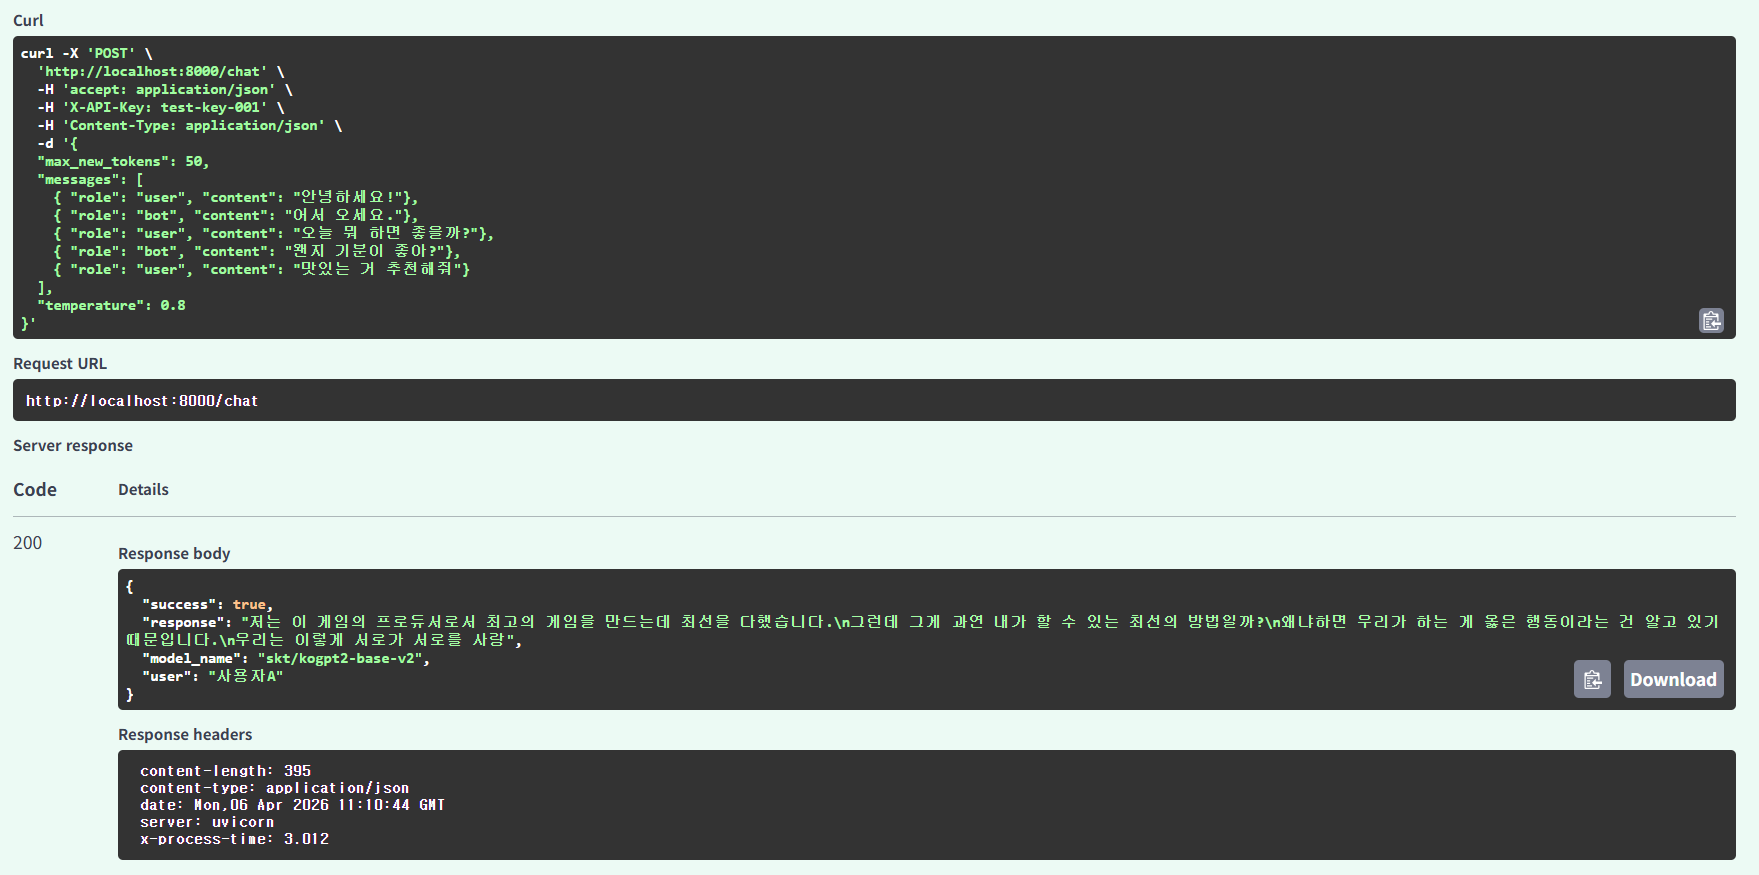
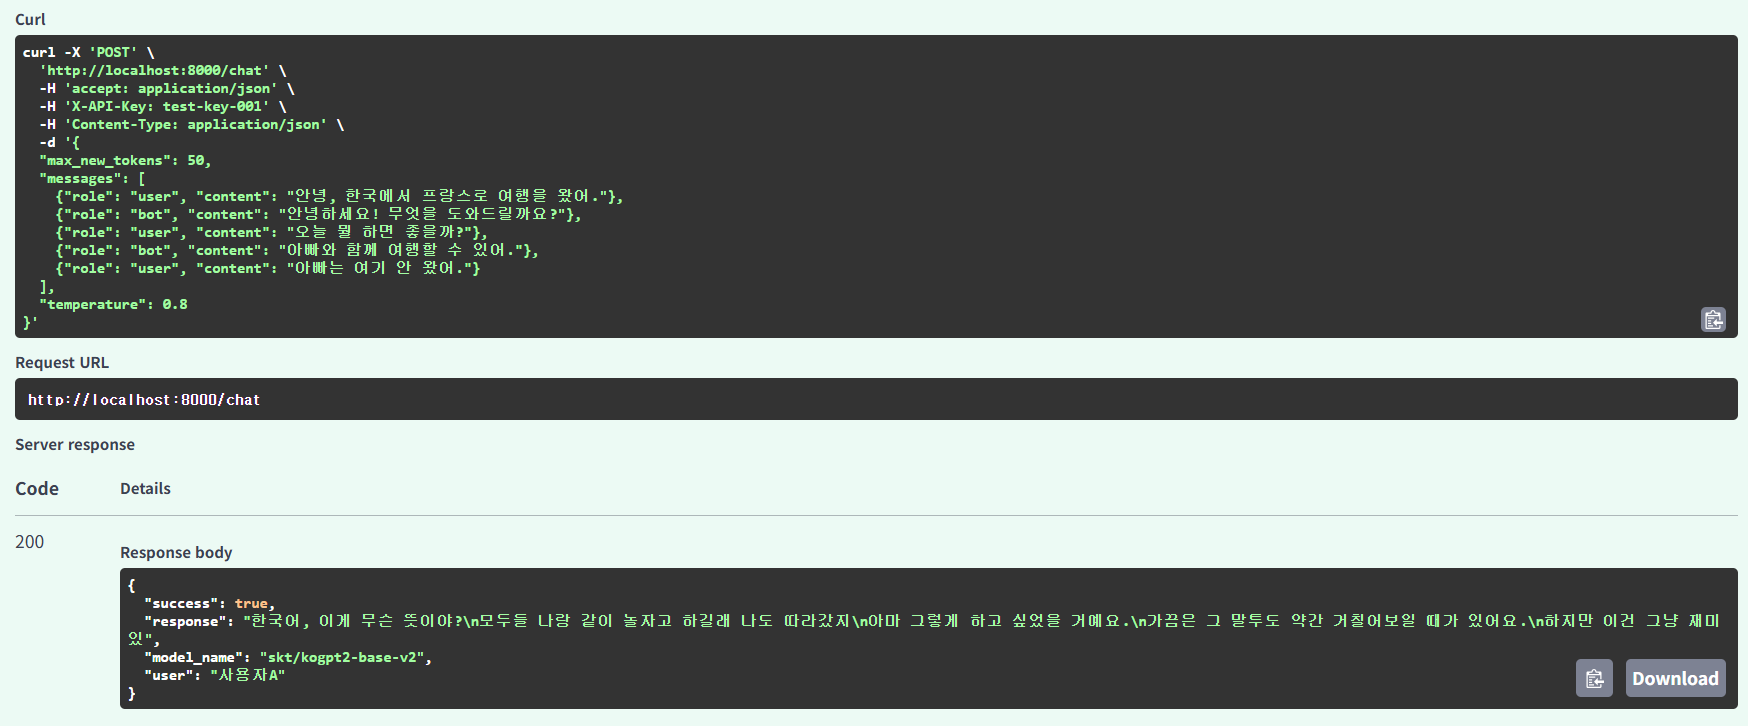

#### 테스트 3: 입력 검증   

In [ ]:
print("[테스트 3] 입력 검증")

# 빈 메시지 목록
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": []},
    headers={"X-API-Key": VALID_KEY})
print(f"  빈 메시지    → HTTP {resp.status_code}")

# temperature 범위 초과
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "테스트"}], "temperature": 5.0},
    headers={"X-API-Key": VALID_KEY})
print(f"  temperature 초과 → HTTP {resp.status_code}")

**빈 메세지**
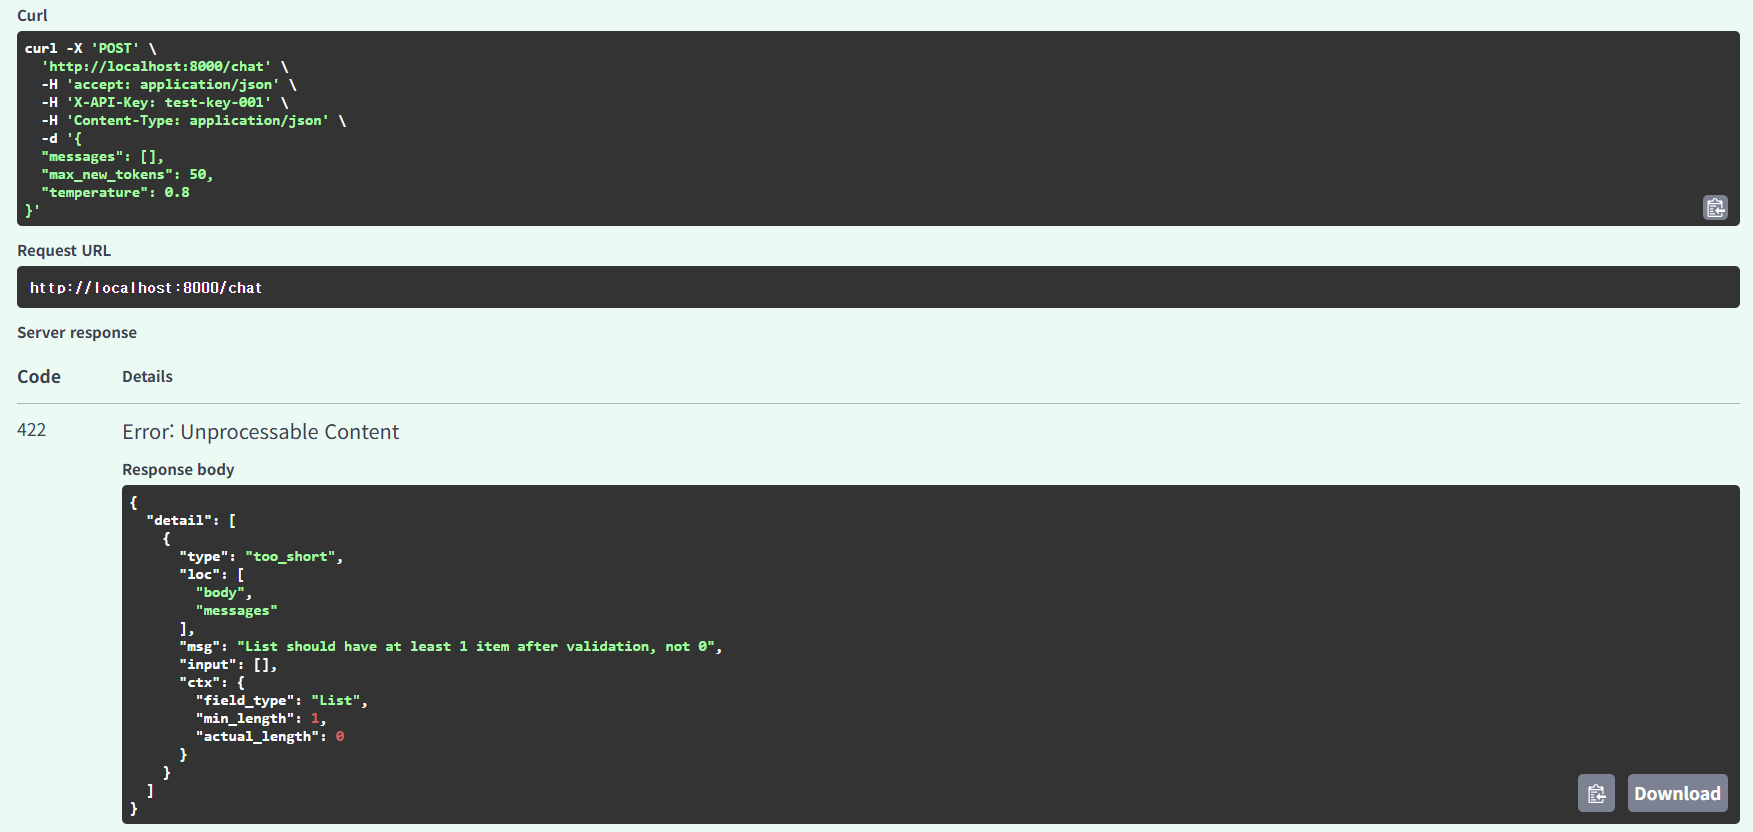

**범위초과**
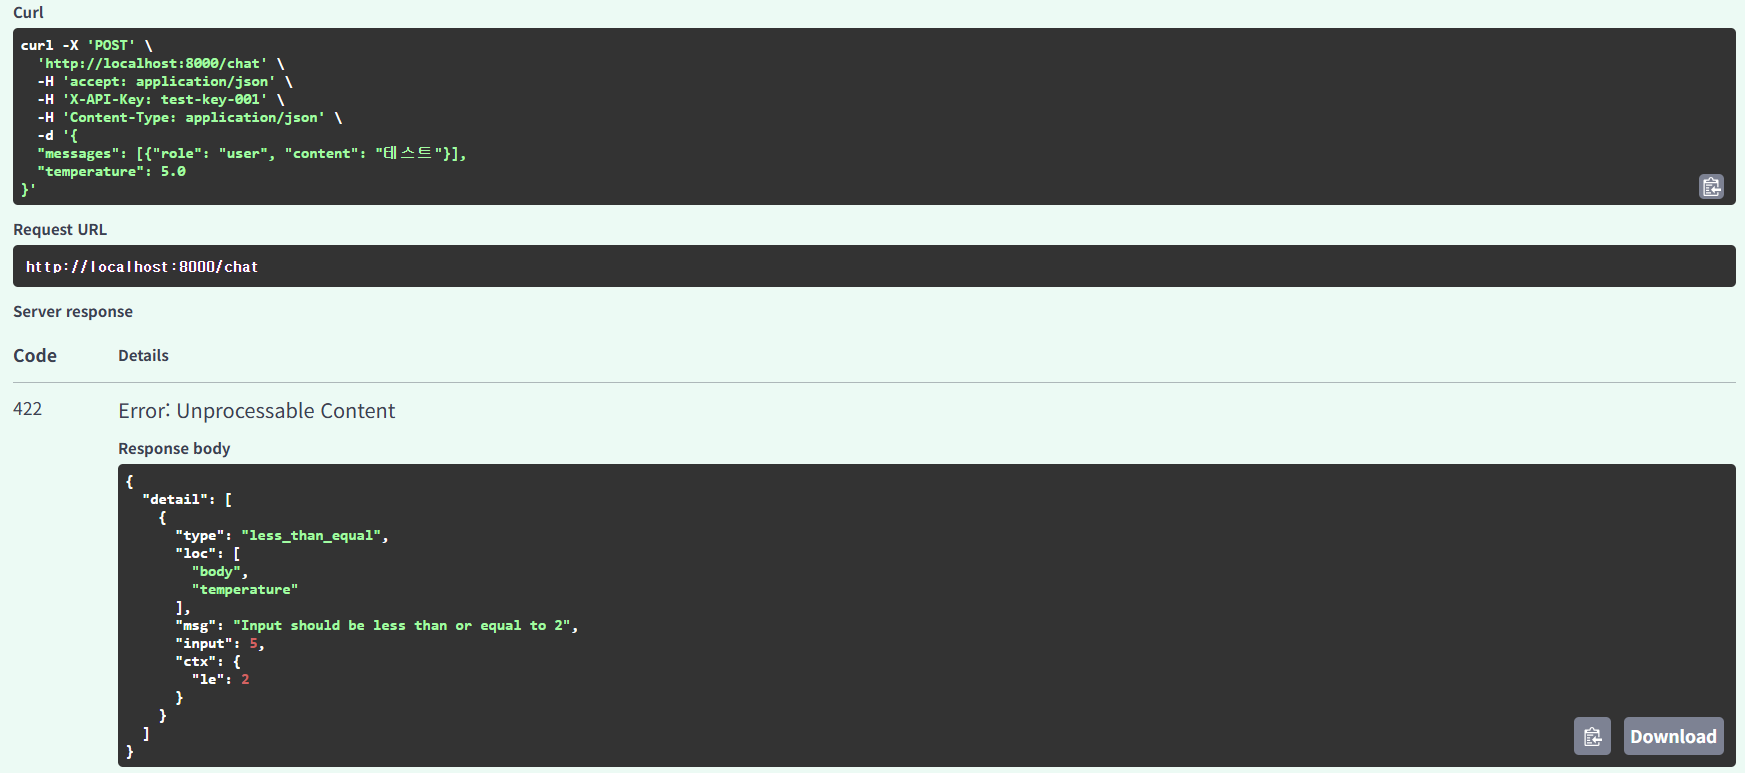

#### 테스트 4: 동시 요청 (tests\test_concurrency.py)

In [ ]:
import time            
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

# 백엔드 서버 주소 및 API 키 설정 (본인의 설정에 맞게 수정)
API_BASE = "http://localhost:8000"
VALID_KEY = "test-key-001"

def send_chat(i):
    start = time.time()
    resp = requests.post(f"{API_BASE}/chat",
        json={"messages": [{"role": "user", "content": f"질문 {i}번입니다"}], "max_new_tokens": 30},
        headers={"X-API-Key": VALID_KEY}, timeout=60)
    return {"id": i+1, "elapsed": round(time.time()-start, 1), "status": resp.status_code}

print("\n[테스트 4] 동시 요청 (4개)")
start = time.time()
with ThreadPoolExecutor(max_workers=4) as ex:
    futures = [ex.submit(send_chat, i) for i in range(4)]
    results = [f.result() for f in as_completed(futures)]

total = round(time.time() - start, 1)
for r in sorted(results, key=lambda x: x["id"]):
    print(f"  요청 #{r['id']}: {r['elapsed']}초 (HTTP {r['status']})")
print(f"  전체: {total}초")

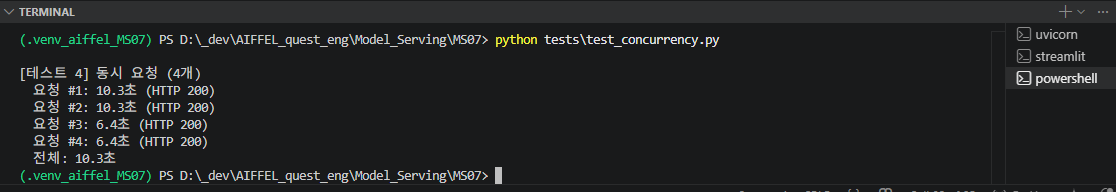

### 6.3 UI 테스트 시나리오

브라우저에서 http://localhost:8501 접속

##### [테스트 A] 기본 대화
  1. 사이드바에 API Key 입력
  2. "안녕하세요" 입력 → 봇 응답 확인
  3. 추가 메시지 입력 → 멀티턴 대화 확인
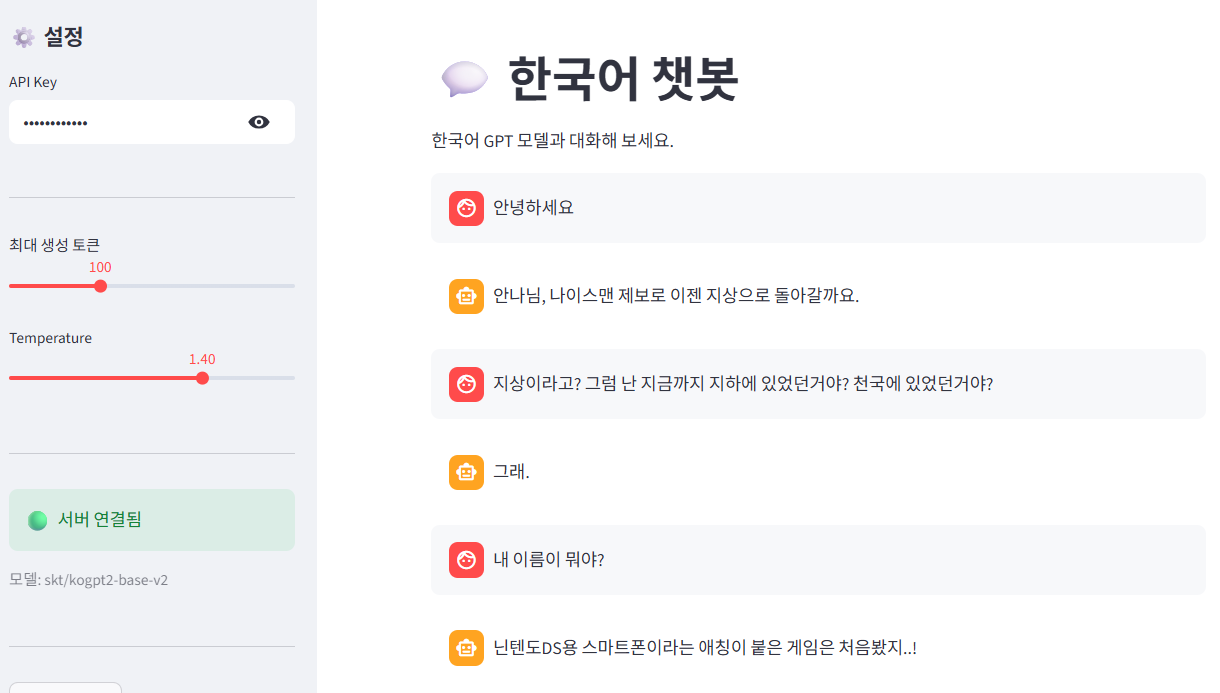

##### [테스트 B] 설정 변경 : 애초부터 아무말 대잔치라 비교가 안됨...!
  1. Temperature를 0.1로 낮추기 → 보수적인 응답 확인  
  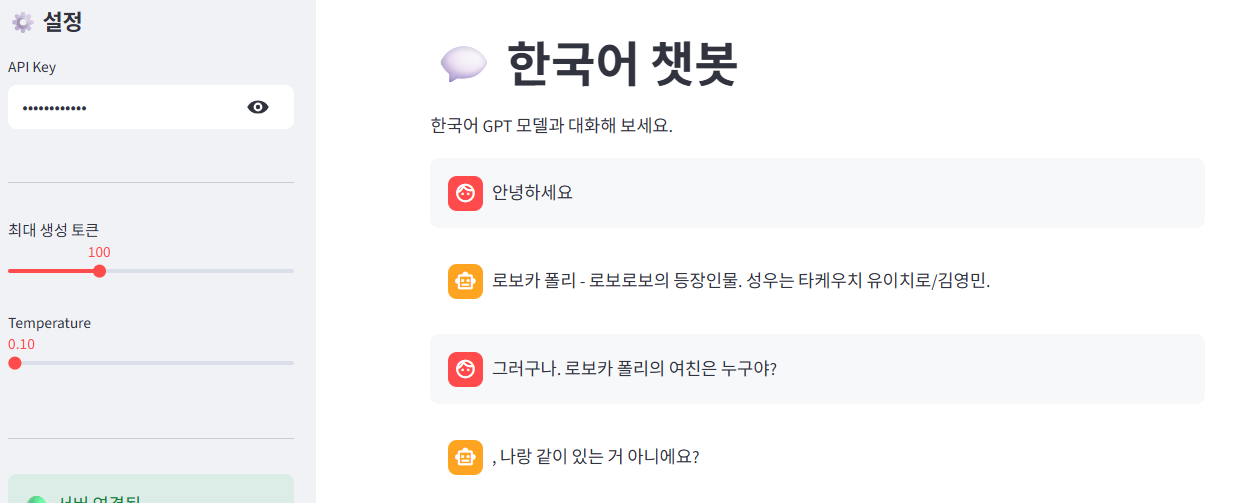
  2. Temperature를 1.5로 올리기 → 다양한 응답 확인  
  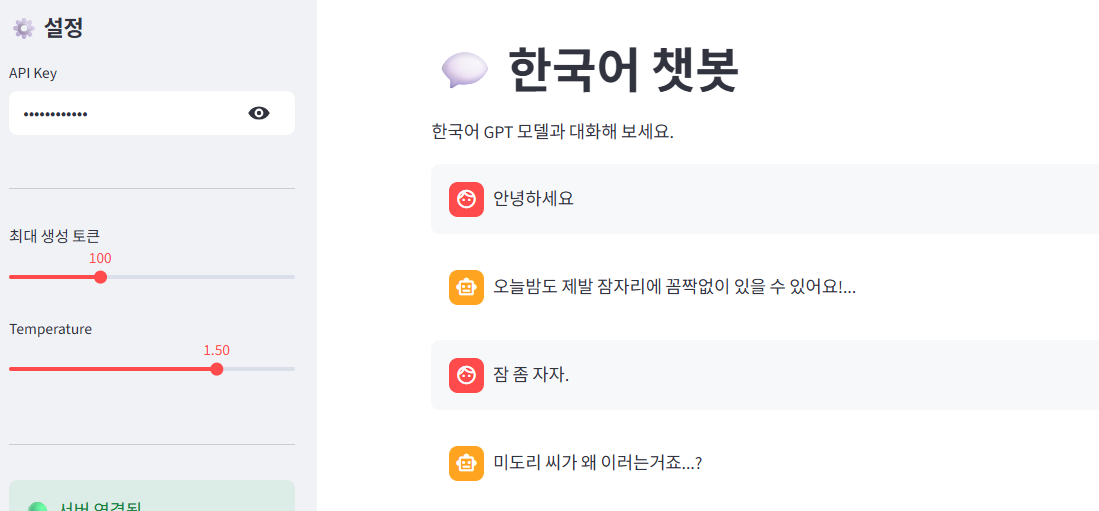

##### [테스트 C] 대화 초기화 : 이건 잘 됨 
  1. 여러 턴 대화 후 "대화 초기화" 클릭
  2. 대화 기록이 사라지는지 확인

##### [테스트 D] 인증 실패
  1. API Key를 wrong-key로 변경
  2. 메시지 입력 → "🔑 인증 실패" 메시지 
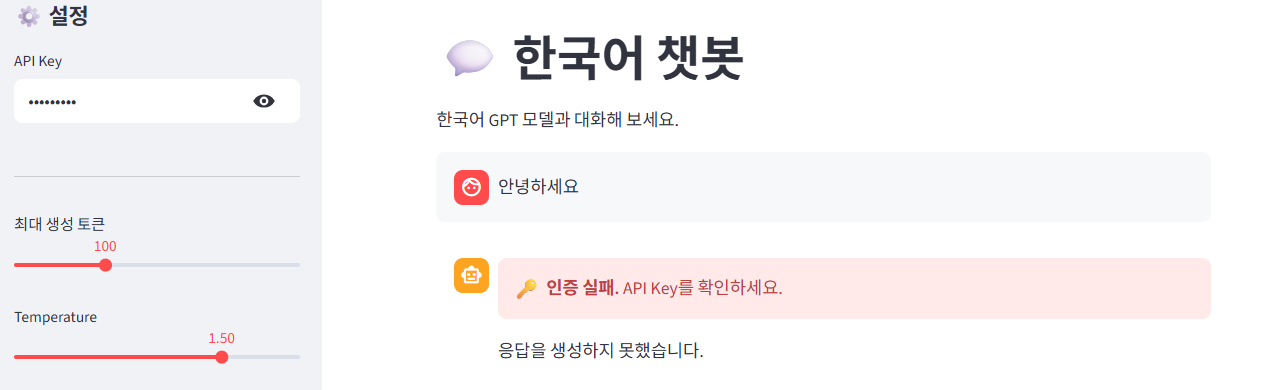

## [오늘의 회고]

#### ✅ FastAPI 백엔드: 챗봇 추론 API 체크포인트

##### 1. ChatRequest의 messages가 리스트인 이유는 무엇입니까?
LLM(거대 언어 모델)은 기본적으로 '상태가 없는(Stateless)' 특성을 가지고 있습니다. 즉, 모델은 방금 전의 질문을 기억하지 못합니다.
- 맥락(Context) 파악: 챗봇이 "그건 얼마야?"라고 물었을 때 "그건"이 무엇인지 알려면 이전 대화 내용이 필요합니다.
- 대화 흐름 유지: 리스트 형태(list[Message])로 대화 전체 기록을 전달함으로써, 모델에게 과거의 대화 이력을 참고하여 현재 질문에 적합한 답변을 생성하도록 하기 위함입니다.
##### 2. 서버가 대화 기록을 저장하지 않고, 클라이언트가 매번 전체 기록을 보내는 이유는?
LLM(거대 언어 모델)은 기본적으로 '상태가 없는(Stateless)' 특성을 가지고 있습니다. 즉, 모델은 방금 전의 질문을 기억하지 못합니다.
- 맥락(Context) 파악: 챗봇이 "그건 얼마야?"라고 물었을 때 "그건"이 무엇인지 알려면 이전 대화 내용이 필요합니다.
- 대화 흐름 유지: 리스트 형태(list[Message])로 대화 전체 기록을 전달함으로써, 모델에게 과거의 대화 이력을 참고하여 현재 질문에 적합한 답변을 생성하도록 하기 위함입니다.
##### 3. max_new_tokens을 너무 크게 설정하면 어떤 문제가 발생할 수 있습니까?
max_new_tokens은 모델이 새로 생성할 답변의 길이를 제한하는 안전장치입니다. 이 값이 너무 크면 다음과 같은 문제가 발생합니다.
- 응답 지연 (Latency): 생성 모델은 토큰을 하나씩 순차적으로 생성합니다. 생성할 토큰 수가 많아질수록 사용자에게 답변이 전달되기까지 걸리는 시간이 길어집니다.
- 자원 과다 소모 및 비용 증가: 더 많은 연산이 필요하므로 GPU/CPU 점유 시간이 길어지고, 클라우드 환경에서는 비용이 더 많이 발생할 수 있습니다.
- 답변 품질 저하 (Hallucination): 모델이 답변을 마친 후에도 지정된 길이를 채우기 위해 엉뚱한 말을 지어내거나, 이전에 했던 말을 무의미하게 반복(Repetition)하는 현상이 발생할 수 있습니다.
- 컨텍스트 제한 초과: 입력된 프롬프트와 새로 생성될 토큰의 합이 모델의 최대 처리 용량(예: 1024 토큰)을 넘어가면 에러가 발생하여 서비스가 중단될 수 있습니다.


#### ✅ Streamlit UI: 채팅 인터페이스 체크포인트

##### 1. `st.chat_message`와 `st.chat_input`은 각각 어떤 역할을 합니까?
이 두 함수는 Streamlit에서 챗봇 인터페이스를 만들기 위해 제공하는 전용 UI 컴포넌트입니다.
- st.chat_message: 채팅 메시지를 표시하는 컨테이너(그릇) 역할을 합니다. with st.chat_message("user"):와 같이 사용하여 메시지의 주체(사용자 또는 어시스턴트)에 따라 서로 다른 아이콘과 배경색을 자동으로 적용해 주어, 실제 메신저와 같은 시각적 효과를 줍니다.
- st.chat_input: 화면 하단에 고정되는 채팅 입력창 역할을 합니다. 사용자가 텍스트를 입력하고 엔터를 치면 해당 값을 반환하며, 일반적인 버튼(st.button)과 달리 채팅 흐름에 최적화된 사용자 경험을 제공합니다.
##### 2. `st.session_state["chat_messages"]`에 대화 기록을 저장하는 이유는?
Streamlit의 독특한 동작 방식 때문입니다.
- 휘발성 방지: Streamlit은 사용자가 버튼을 누르거나 값을 입력하는 등 상호작용이 발생할 때마다 스크립트 전체를 처음부터 끝까지 다시 실행합니다. 이때 일반 변수에 저장된 값은 모두 초기화되어 사라집니다.
- 데이터 유지: st.session_state는 브라우저 탭이 열려 있는 동안 데이터를 유지해 주는 저장소입니다. 여기에 대화 기록을 담아두어야 스크립트가 재실행되어도 이전 대화 내용이 사라지지 않고 화면에 계속 표시될 수 있으며, 다음 API 호출 시 전체 맥락(Context)을 서버로 보낼 수 있습니다.
##### 3. "대화 초기화" 버튼이 `st.rerun()`을 호출하는 이유는 무엇입니까?
사용자에게 깨끗해진 화면을 즉각적으로 보여주기 위해서입니다.
- 상태 업데이트: 버튼을 클릭하면 st.session_state["chat_messages"] = [] 코드가 실행되어 메모리상의 대화 기록은 비워집니다.
- 화면 갱신 강제: 하지만 스크립트가 이미 아래쪽 코드(메시지를 화면에 그리는 부분)를 지나쳐 버렸다면, 화면에는 여전히 이전 대화가 남아 있을 수 있습니다.
- 즉시 반영: 이때 st.rerun()을 호출하면 Streamlit이 즉시 스크립트를 처음부터 다시 실행합니다. 재실행된 스크립트는 비어 있는 st.session_state를 참조하여 아무 메시지도 없는 깨끗한 채팅창을 화면에 그려내게 됩니다.


#### ✅ API Key 인증 적용 및 에러 처리 체크포인트

##### 1. `st.chat_message`와 `st.chat_input`은 각각 어떤 역할을 합니까?
이 두 함수는 Streamlit에서 챗봇 인터페이스를 만들기 위해 제공하는 전용 UI 컴포넌트입니다.
- st.chat_message: 채팅 메시지를 표시하는 전용 컨테이너(그릇) 역할을 합니다. with st.chat_message("user"):와 같이 사용하여 메시지의 주체(사용자 또는 어시스턴트)에 따라 서로 다른 아이콘과 배경색을 자동으로 적용해 주어, 실제 메신저와 같은 시각적 효과를 줍니다.
- st.chat_input: 화면 하단에 고정되는 채팅 전용 입력창 역할을 합니다. 사용자가 텍스트를 입력하고 엔터를 치면 해당 값을 반환하며, 일반적인 버튼(st.button)과 달리 채팅 흐름에 최적화된 사용자 경험을 제공합니다.

##### 2. `st.session_state["chat_messages"]`에 대화 기록을 저장하는 이유는?
Streamlit의 독특한 동작 방식 때문입니다.
- 휘발성 방지: Streamlit은 사용자가 버튼을 누르거나 값을 입력하는 등 상호작용이 발생할 때마다 스크립트 전체를 처음부터 끝까지 다시 실행합니다. 이때 일반 변수에 저장된 값은 모두 초기화되어 사라집니다.
- 데이터 유지: st.session_state는 브라우저 탭이 열려 있는 동안 데이터를 유지해 주는 저장소입니다. 여기에 대화 기록을 담아두어야 스크립트가 재실행되어도 이전 대화 내용이 사라지지 않고 화면에 계속 표시될 수 있으며, 다음 API 호출 시 전체 맥락(Context)을 서버로 보낼 수 있습니다.

##### 3. "대화 초기화" 버튼이 `st.rerun()`을 호출하는 이유는 무엇입니까?
사용자에게 깨끗해진 화면을 즉각적으로 보여주기 위해서입니다.
- 상태 업데이트: 버튼을 클릭하면 st.session_state["chat_messages"] = [] 코드가 실행되어 메모리상의 대화 기록은 비워집니다.
- 화면 갱신 강제: 하지만 스크립트가 이미 아래쪽 코드(메시지를 화면에 그리는 부분)를 지나쳐 버렸다면, 화면에는 여전히 이전 대화가 남아 보일 수 있습니다.
- 즉시 반영: 이때 st.rerun()을 호출하면 현재 실행 중인 스크립트를 즉시 중단하고 처음부터 다시 실행합니다. 재실행된 스크립트는 비어 있는 st.session_state를 참조하여 아무 메시지도 없는 깨끗한 채팅창을 화면에 그려내게 됩니다.

### 📝MEMO

- 로컬 환경에서는 커널을 지정하지 않으면 실행되지 않는다!
- git 안에 서브폴더에 가상환경을 설정하는 경우 .gitignore 에 명시해 두자.
- git 안에 git을 두는 것은 바람직 하지 않다. 배포만, 단독으로 하자

**본 프로젝트를 위해 필수 설치해야하는 패키지**  
transformers accelerate uvicorn nest-asyncio requests



#### 1. git add . 시 Warning message


```
warning: in the working copy of 'Model_Serving/MS07/MS06_Theory_Auth_Mechanisms.ipynb', LF will be replaced by CRLF the next time Git touches it
warning: in the working copy of 'Model_Serving/MS07/MS07_TransformerChatbotProject.ipynb', LF will be replaced by CRLF the next time Git touches it
```

##### 1) 원인: LF vs CRLF
운영체제에 따라 문장의 끝(줄 바꿈)을 인식하는 방식이 다름
- LF (Line Feed): Unix, macOS, Linux에서 사용하는 방식입니다. (\n)
- CRLF (Carriage Return Line Feed): Windows에서 사용하는 방식입니다. (\r\n)  
☞ 현재 Windows 환경에서 작업을 하고 있는데, 추가하려는 파일(MS06_Theory_Auth_Mechanisms.ipynb 등)이 LF 방식으로 저장되어 있어, Git이 이를 CRLF로 자동 변환하여 저장하겠다고 알려주는 것

##### 2) 해결 방법: Git 설정 변경
- 이 경고를 해결하고 협업 시 줄 바꿈 혼란을 방지하기 위해 Git 설정을 변경하는 것이 좋음
- 터미널(또는 VS Code 터미널)에 아래 명령어 입력    

**(1) Windows 사용자라면:**
 
```
git config --global core.autocrlf true

```

**(2) 만약 경고 메시지 자체를 더 이상 보고 싶지 않다면 (경고 끄기):**

```
git config --global core.safecrlf false
```



#### 2. 백엔드는 끄지 말자.

##### 1) 백엔드를 끄지 않아도 되는 이유 (효율성)
- **GPT 모델(Trinity 1.2B 또는 KoGPT2)**은 용량이 꽤 커서, 서버를 켤 때마다 모델을 메모리에 올리는 데 시간이 수십 초에서 수분까지 걸림
- 백엔드를 켜두면 모델이 이미 메모리에 로드된 상태이므로, 프론트엔드를 수정하거나 패키지를 설치한 뒤 바로 테스트해도 즉시 응답됨.
- pip install은 서버가 돌아가는 중에도 독립적으로 수행될 수 있음

##### 2) 백엔드를 꺼야 할 때
- app/chatbot_api.py나 app/auth.py 등 백엔드 코드를 수정했는데 자동 재시작(--reload)이 제대로 안 될 때.
- GPU 메모리(VRAM)가 부족해서 프론트엔드가 실행이 안 될 때 (이런 경우는 드뭅니다).
- 포트 번호를 바꿔야 할 때.

### **모델은 좋은 걸로 쓰자**